# Assignment 6: Data Scraping
```
Course: ENV 700 - Environmental Data Exploration
Author: Xiyu Wang
Date: Fall 2026
```

This notebook accompanies the Python lessons on **Data Scraping**. We'll be scraping data from the North Carolina Department of Water Quality (NC DWQ). 

## 1. Setup
* Import packages: `requests`, `BeautifulSoup` (from `bs4`), `pandas` (as `pd`), `seaborn` (as `sns`) and any other packages you wish to use. 
* Set your Seaborn theme's style, context, and any runtime configurations you wish

In [1]:
#Import packages
import requests
from bs4 import BeautifulSoup
import pandas as pd
import seaborn as sns

#Set Seaborn theme
sns.set_theme(style='darkgrid', context='notebook')

## 2. Scraping Water Supply Data 
We will be scraping data from the NC DEQs Local Water Supply Planning website, specifically the Durham's 2025 Municipal Local Water Supply Plan (LWSP): 
 * Navigate to https://www.ncwater.org/WUDC/app/LWSP/search.php
 * Set the year to 2025
 * Scroll down and select the LWSP link next to Durham Municipality. 
 * Note the web address: <https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025>

---
### 2.1 Retrieve the website and parse it using BeautifulSoup

In [2]:
# 2.1 Retrieve the website and parse it using BeautifulSoup
response = requests.get('https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid=03-32-010&year=2025')
the_website = BeautifulSoup(response.text, 'html.parser')

### 2.2 The data we want to collect are listed below:

* From the **1. System Information** section:
    - Water system name
    - Contact Person
    - Ownership
 
* From the **3. Water Supply Sources** section:
    - Maximum Day Use (MGD) - for each month

In the code chunk below scrape these values, assigning them to four separate variables.  
>HINT: The first value should be "`Durham`", the second "`Kieu Tran`", the third "`Municipality`", and the last should be a vector of 12 numeric values (represented as strings)".

In [3]:
# 2.2 Scrape the data into variables
system_info = the_website.select('td:nth-child(2)')

water_system = system_info[0].get_text(strip=True)
contact_person = system_info[2].get_text(strip=True)

ownership_nodes = the_website.select('td:nth-child(4)')
ownership = ownership_nodes[1].get_text(strip=True)

the_max_day_use = [
    x.get_text(strip=True)
    for x in the_website.select("th~ td+ td")
]

In [4]:
print(water_system)
print(contact_person)
print(ownership)
print(the_max_day_use)

Durham
Kieu Tran
Municipality
['40.2400', '37.3800', '37.9100', '33.8100', '36.8400', '36.9000', '36.5300', '38.0400', '33.8000', '37.9500', '35.2000', '32.2000']


### 2.3 Construct a dataframe from the scraped data
Convert your scraped data into a dataframe. 
* This dataframe should have a column for each of the 4 variables scraped and a row for the month corresponding to the withdrawal data. 
* Note that you won't likely be able to scrape max water usage data in chronological order.
* Include columns for the month and year the data were collected. 
* Sort the data on year and month.
* Construct a datetime column from the year and month, assuming the day of the month will be the first. 

>🔥**TIP**: : To construct a list from a repeated set of values, use this approach:
>```python
>years_x6 = [2025] * 6
>print(years_x6)
>```

>🔥**TIP**: To construct a datetime column when you just the year and month, you can use the following:
>```python
>df['Date'] = pd.to_datetime({
>    "year": df['Year'],
>    "month": df['Month'],
>    "day": 1
>})
>```

In [5]:
# 2.3 Construct the dataframe from scraped data
month = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]

df_water = pd.DataFrame({
    "Month": month,
    "Year": 2025,
    "Max_Day_Use_MGD": pd.to_numeric(the_max_day_use),
    "Water_System": water_system,
    "Contact_Person": contact_person,
    "Ownership": ownership,
})

df_water["Date"] = pd.to_datetime(
    dict(year=df_water["Year"], month=df_water["Month"], day=1)
)

df_water = df_water.sort_values("Date").reset_index(drop=True)

df_water.head()

,Month,Year,Max_Day_Use_MGD,Water_System,Contact_Person,Ownership,Date
0,1,2025,40.24,Durham,Kieu Tran,Municipality,2025-01-01
1,2,2025,33.81,Durham,Kieu Tran,Municipality,2025-02-01
2,3,2025,36.53,Durham,Kieu Tran,Municipality,2025-03-01
3,4,2025,37.95,Durham,Kieu Tran,Municipality,2025-04-01
4,5,2025,37.38,Durham,Kieu Tran,Municipality,2025-05-01


### 2.4 Plot the data
* Create a line plot of the maximum daily withdrawals across the months for 2024
* Label the x-axis with month names or abbreviated month names. (Note, you may have to do some more wrangling...)

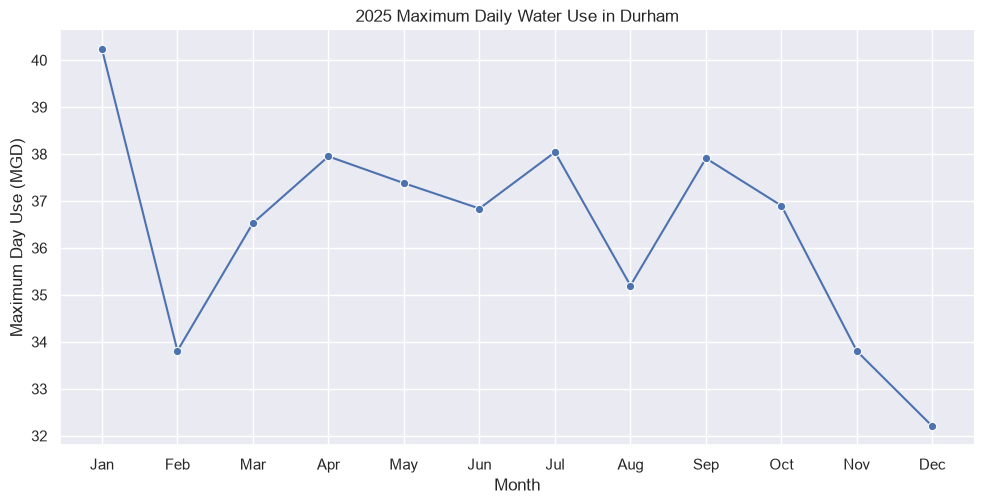

In [6]:
# 2.4 Plot the data
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

df_water["Month_Name"] = month_names

g = sns.relplot(
    data=df_water,
    x="Month_Name",
    y="Max_Day_Use_MGD",
    kind="line",
    marker="o",
    aspect=2
)

g.set(
    title="2025 Maximum Daily Water Use in Durham",
    xlabel="Month",
    ylabel="Maximum Day Use (MGD)"
);

## 3. Automating the Scraping Process
### 3.1 Construct the scraping function
Note that the PWSID and the year appear in the web address for the page we scraped. Construct a function with two inputs, "PWSID" and "year", that:
  - Creates a URL pointing to the LWSP for that PWSID for the given year
  - Creates a website object and scrapes the data from that object (just as you did above)
  - Constructs a dataframe from the scraped data, mostly as you did above, but includes the PWSID and year provided as function inputs in the dataframe. 
  - Returns the dataframe as the function's output

In [7]:
# 3.1 Create a scraping function
def scrape_LWSP(PWSID, year):

    url = f"https://www.ncwater.org/WUDC/app/LWSP/report.php?pwsid={PWSID}&year={year}"

    response = requests.get(url)
    response.raise_for_status()
    the_website = BeautifulSoup(response.text, "html.parser")

    system_info_nodes = the_website.select('td:nth-child(2)')
    water_system = system_info_nodes[0].get_text(strip=True)
    contact_person = system_info_nodes[2].get_text(strip=True)

    ownership_nodes = the_website.select('td:nth-child(4)')
    ownership = ownership_nodes[1].get_text(strip=True)

    the_max_day_use = [
        x.get_text(strip=True)
        for x in the_website.select("th~ td+ td")
    ]

    month = [1, 5, 9, 2, 6, 10, 3, 7, 11, 4, 8, 12]

    df_water = pd.DataFrame({
        "Month": month,
        "Year": year,
        "PWSID": PWSID,
        "Max_Day_Use_MGD": pd.to_numeric(the_max_day_use),
        "Water_System": water_system,
        "Contact_Person": contact_person,
        "Ownership": ownership,
    })

    df_water["Date"] = pd.to_datetime(
        dict(year=df_water["Year"], month=df_water["Month"], day=1)
    )

    df_water = df_water.sort_values("Date")

    return df_water

### 3.2 Fetch and plot data for Durham (PWSID=`03-32-010`) in 2020
* Use the function above to extract and plot max daily withdrawals for Durham (PWSID=`03-32-010`) for each month in 2020.
* Reveal the structure of your dataframe using the `info()` function. 
* Then create plot your data in a line plot as above: Max Usage by Month.

In [8]:
# 3.2.1 Scrape data for 03-32-010 in 2020 & display its structure
df_2020 = scrape_LWSP("03-32-010", 2020)
df_2020.info()

<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Month            12 non-null     int64         
 1   Year             12 non-null     int64         
 2   PWSID            12 non-null     str           
 3   Max_Day_Use_MGD  12 non-null     float64       
 4   Water_System     12 non-null     str           
 5   Contact_Person   12 non-null     str           
 6   Ownership        12 non-null     str           
 7   Date             12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 864.0 bytes


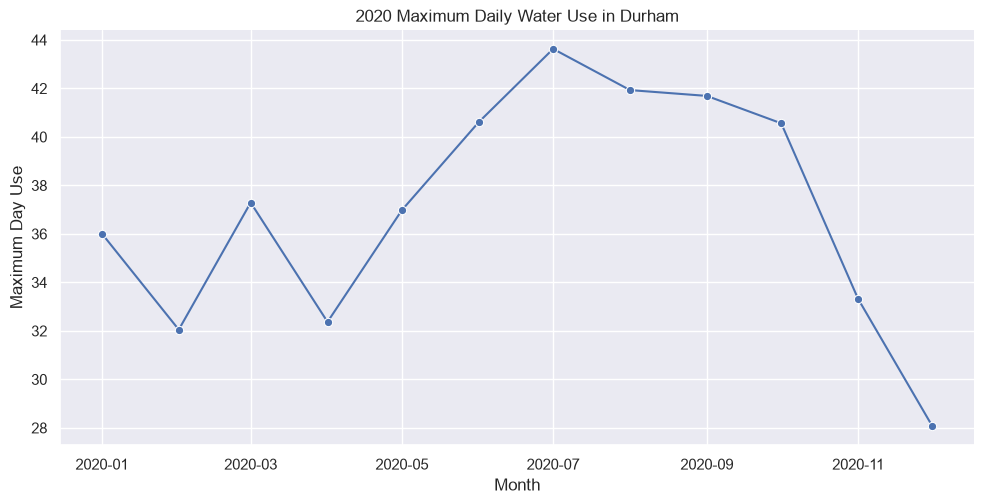

In [9]:
# 3.2.2 Plot the data
g = sns.relplot(
    data=df_2020,
    x="Date",
    y="Max_Day_Use_MGD",
    kind="line",
    marker="o",
    aspect=2
)

g.set(
    title="2020 Maximum Daily Water Use in Durham",
    xlabel="Month",
    ylabel="Maximum Day Use"
);

### 3.3 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020

In [10]:
# 3.3.1 Fetch and plot data for Cary (PWSID=`03-92-020`) in 2020
df_cary_2020 = scrape_LWSP("03-92-020", 2020)
df_cary_2020.info()

<class 'pandas.DataFrame'>
Index: 12 entries, 0 to 11
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Month            12 non-null     int64         
 1   Year             12 non-null     int64         
 2   PWSID            12 non-null     str           
 3   Max_Day_Use_MGD  12 non-null     float64       
 4   Water_System     12 non-null     str           
 5   Contact_Person   12 non-null     str           
 6   Ownership        12 non-null     str           
 7   Date             12 non-null     datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(4)
memory usage: 864.0 bytes


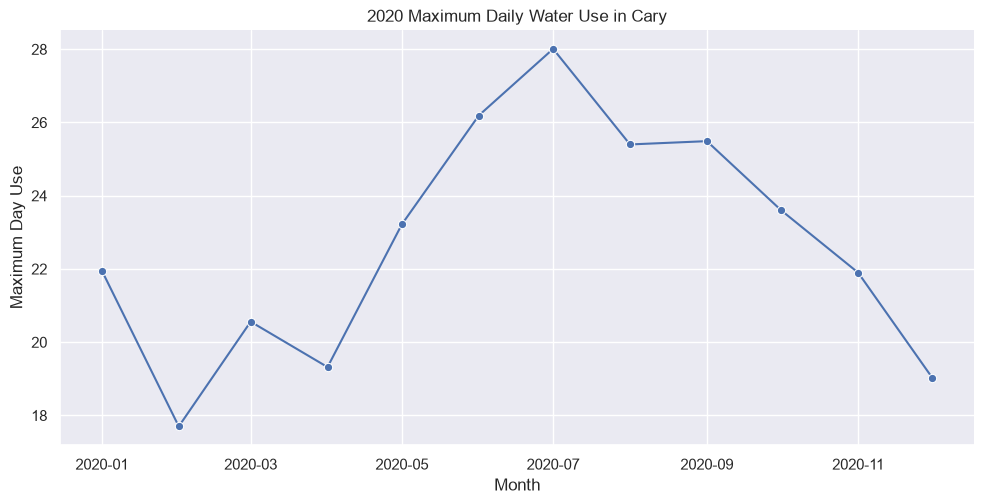

In [11]:
# 3.3.2 Plot the Cary data
g = sns.relplot(
    data=df_cary_2020,
    x="Date",
    y="Max_Day_Use_MGD",
    kind="line",
    marker="o",
    aspect=2
)

g.set(
    title="2020 Maximum Daily Water Use in Cary",
    xlabel="Month",
    ylabel="Maximum Day Use"
);

### 3.4 Examine monthy max discharge from 2020-2025
* Use list comprehension (or other methods) to produce a list of dataframes, one for each year in 2020 to 2025
* Concatenate these dataframes into a single one including data for all years
* Create a line plot of max monthly discharge across the full timespan (x-axis labels do not have to be months)

In [14]:
# 3.4.1 Generate a list of the dataframes
the_years = range(2020, 2026)

the_dfs = [scrape_LWSP("03-32-010", year) for year in the_years]

# 3.4.2 Combine them into a single dataframe
the_df = pd.concat(the_dfs, ignore_index=True)

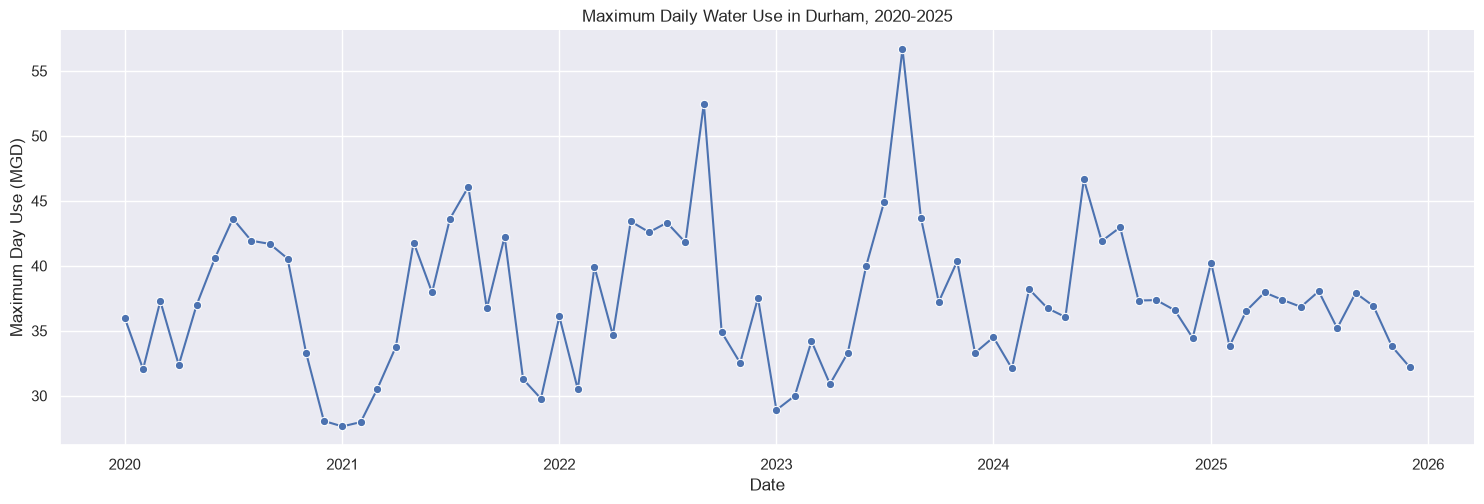

In [16]:
# 3.4.3 Plot
g = sns.relplot(
    data=the_df,
    x="Date",
    y="Max_Day_Use_MGD",
    kind="line",
    aspect=3,
    marker="o"
)

g.set(
    title="Maximum Daily Water Use in Durham, 2020-2025",
    xlabel="Date",
    ylabel="Maximum Day Use (MGD)"
);